# Posterior on Ω_b h² from primordial abundances

For each value of Ω_b h² in a grid around the Planck value, we run a Monte Carlo
over nuclear rates to obtain the theoretical prediction and its uncertainty.
We then compute a Gaussian likelihood

$$
\mathcal{L}(\Omega_b h^2 \mid O_{\rm obs}) \propto
\exp\!\left(-\frac{(O_{\\m th} - O_{\rm obs})^2}{2(\sigma_{\rm th}^2 + \sigma_{\\m obs}^2)}\right)
$$

and plot the combined posterior from $Y_P$ and D/H.

**Observational constraints used:**
- $Y_P$: Yeh et al. 2026 — $0.2458 \pm 0.0013$
- D/H: Cooke et al. 2018 — $(2.527 \pm 0.030) \times 10^{-5}$

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats import norm
import multiprocessing

from primat.backend import run_mc

**Note on backends.** `run_mc`'s results are recoverable identically from either the C or the pure-Python backend: both return the same `MCResult` shape (`mc['key'].mean`/`.std`/`.values`/`.central`, `mc.quantity_names()`, `mc.samples_array()`). Samples are *statistically* (not bit-for-bit) comparable between backends -- the C backend draws with a pthread/xoshiro256** RNG, the Python backend with joblib/numpy's `default_rng` -- so the same seed will not reproduce identical sample values across backends, only matching means/stds at large `num_mc`. Per-sample TSV export is available via `primat.backend.dump_mc_samples(mc)`.


In [2]:
# Observational constraints (central value, 1σ)
OBS = {
    'YPBBN': (0.2458,   0.0013,   r'$Y_P$ — Yeh+25'),
    'DoH':   (2.527e-5, 0.030e-5, r'D/H — Cooke+18'),
}

# Ω_b h² grid centred on the Planck value
Omegabh2_vec = np.arange(0.0200, 0.02401, 0.00025)
npoints = len(Omegabh2_vec)

num_mc  = 100    # increase for paper quality (~500)
num_cpu = multiprocessing.cpu_count()

base_opts = {
    'network':     'small',
}

print(f"Grid: {npoints} points, {num_mc} MC samples each = {npoints*num_mc} total runs")
print(f"Running on {num_cpu} CPUs")

Grid: 17 points, 100 MC samples each = 1700 total runs
Running on 8 CPUs


In [3]:
# Run MC at each Ω_b h² point
quantities = ['YPBBN', 'DoH']

results = {q: {'central': np.zeros(npoints), 'std': np.zeros(npoints)}
           for q in quantities}

# Same seed at every grid point: sample j draws the same p_* vector everywhere,
# so finite-MC bias is correlated across the grid and cancels when comparing points.
MC_SEED = 0

for i, ob2 in enumerate(Omegabh2_vec):
    print(f"  Ω_b h² = {ob2:.4f}  ({i+1}/{npoints})", flush=True)
    mc = run_mc(num_mc, quantities,
                params={**base_opts, 'Omegabh2': ob2},
                n_jobs=num_cpu, seed=MC_SEED)
    for q in quantities:
        results[q]['central'][i] = mc[q].central
        results[q]['std'][i]     = mc[q].std

print("Done.")

  Ω_b h² = 0.0200  (1/17)
  Ω_b h² = 0.0203  (2/17)
  Ω_b h² = 0.0205  (3/17)
  Ω_b h² = 0.0208  (4/17)
  Ω_b h² = 0.0210  (5/17)
  Ω_b h² = 0.0213  (6/17)
  Ω_b h² = 0.0215  (7/17)
  Ω_b h² = 0.0218  (8/17)
  Ω_b h² = 0.0220  (9/17)
  Ω_b h² = 0.0223  (10/17)
  Ω_b h² = 0.0225  (11/17)
  Ω_b h² = 0.0228  (12/17)
  Ω_b h² = 0.0230  (13/17)
  Ω_b h² = 0.0233  (14/17)
  Ω_b h² = 0.0235  (15/17)
  Ω_b h² = 0.0238  (16/17)
  Ω_b h² = 0.0240  (17/17)
Done.


In [4]:
# Compute Gaussian likelihoods and combined posterior
x = Omegabh2_vec
xfine = np.linspace(x[0], x[-1], 500)

likelihoods = {}
for key, (obs_val, obs_err, _) in OBS.items():
    th_val = results[key]['central']
    th_err = results[key]['std']
    sigma2 = th_err**2 + obs_err**2
    log_L  = -0.5 * (th_val - obs_val)**2 / sigma2
    L      = np.exp(log_L - log_L.max())
    L_fine = interp1d(x, L, kind='cubic')(xfine)
    L_fine = np.clip(L_fine, 0, None)
    L_fine /= L_fine.max()
    likelihoods[key] = L_fine

# Combined posterior
log_combined = sum(np.log(np.clip(L, 1e-300, None)) for L in likelihoods.values())
combined = np.exp(log_combined - log_combined.max())

print("Likelihoods computed.")

Likelihoods computed.


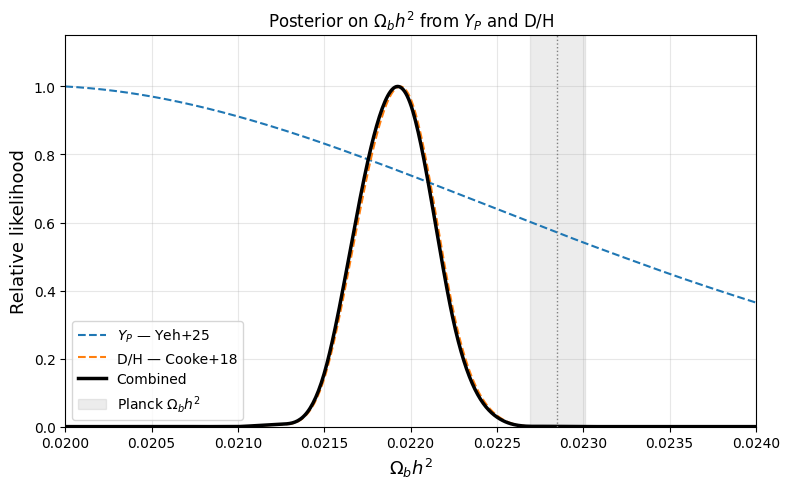

Saved plots/posterior_baryons.pdf


In [5]:
# Plot individual likelihoods and combined posterior
colors = {
    'YPBBN': ('tab:blue',   OBS['YPBBN'][2]),
    'DoH':   ('tab:orange', OBS['DoH'][2]),
}

planck_val, planck_err = 0.02285, 0.00016

fig, ax = plt.subplots(figsize=(8, 5))

for key, (color, label) in colors.items():
    ax.plot(xfine, likelihoods[key], color=color, lw=1.5, ls='--', label=label)

ax.plot(xfine, combined, color='black', lw=2.5, label='Combined')

ax.axvspan(planck_val - planck_err, planck_val + planck_err,
           alpha=0.15, color='gray', label=r'Planck $\Omega_b h^2$')
ax.axvline(planck_val, color='gray', lw=1, ls=':')

ax.set_xlabel(r'$\Omega_b h^2$', fontsize=13)
ax.set_ylabel('Relative likelihood', fontsize=13)
ax.set_xlim(x[0], x[-1])
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_title(r'Posterior on $\Omega_b h^2$ from $Y_P$ and D/H', fontsize=12)

plt.tight_layout()
plt.savefig('plots/posterior_baryons.pdf', bbox_inches='tight')
plt.show()
print("Saved plots/posterior_baryons.pdf")

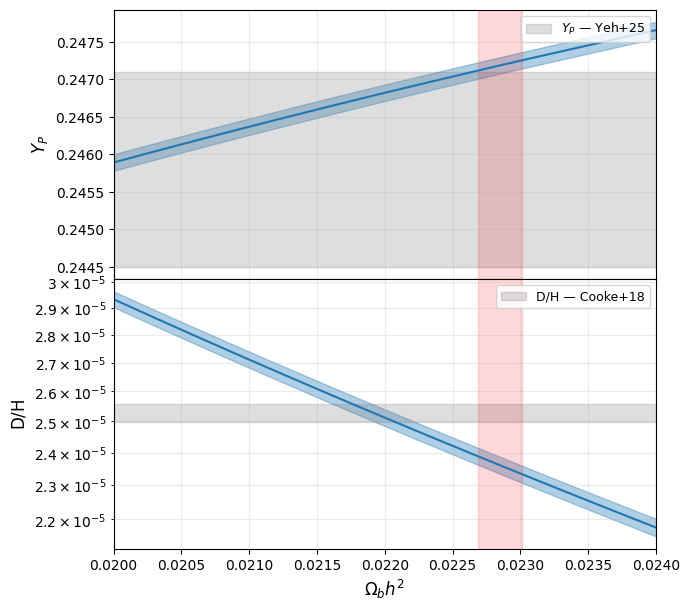

Saved plots/posterior_baryons_abundances.jpg


In [6]:
# Abundance predictions with uncertainty bands vs Ω_b h²
panel_info = [
    ('YPBBN', r'$Y_P$',     False, OBS['YPBBN']),
    ('DoH',   r'$\rm D/H$', True,  OBS['DoH']),
]

fig, axs = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
fig.subplots_adjust(hspace=0)

for ax, (key, ylabel, log, (obs_val, obs_err, obs_label)) in zip(axs, panel_info):
    th  = results[key]['central']
    err = results[key]['std']
    th_fine = interp1d(x, th,       kind='cubic')(xfine)
    lo_fine = interp1d(x, th - err, kind='cubic')(xfine)
    hi_fine = interp1d(x, th + err, kind='cubic')(xfine)

    ax.fill_between(xfine, lo_fine, hi_fine, alpha=0.35, color='tab:blue')
    ax.plot(xfine, th_fine, color='tab:blue', lw=1.5)
    ax.axhspan(obs_val - obs_err, obs_val + obs_err,
               alpha=0.25, color='tab:gray', label=obs_label)
    ax.axvspan(planck_val - planck_err, planck_val + planck_err,
               alpha=0.15, color='red')
    ax.set_ylabel(ylabel, fontsize=12)
    if log:
        ax.set_yscale('log')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, which='both', alpha=0.25)
    ax.tick_params(labelsize=10)

axs[-1].set_xlabel(r'$\Omega_b h^2$', fontsize=12)
for ax in axs:
    ax.set_xlim(x[0], x[-1])

plt.savefig('plots/posterior_baryons_abundances.jpg', bbox_inches='tight')
plt.show()
print("Saved plots/posterior_baryons_abundances.jpg")